# Part 5: KNN and a Mini Neural Network — Two Ways to Learn
**⏱ This section takes approximately 40 minutes.**

---

In the earlier parts you saw *what* machine learning is. Now we open the hood on **two
algorithms that learn in completely opposite ways** — and we build both from scratch with
nothing but NumPy, so there is no magic left.

| | K-Nearest Neighbors | Mini Neural Network |
|---|---|---|
| **Idea** | “You are like your neighbors” | “Adjust weights until the error shrinks” |
| **Learning style** | *Lazy* — just stores the data | *Eager* — trains parameters up front |
| **Has learned parameters?** | No (non-parametric) | Yes (the weights) |
| **Work happens at…** | prediction time | training time |

We'll validate our hand-written KNN against scikit-learn, then train a tiny network to solve
**XOR** — the classic problem a single straight line *cannot* solve.

## Setup

Run this cell first. It imports the libraries and fixes the random seed so your results match
this notebook exactly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
np.random.seed(42)
print('Setup complete — NumPy', np.__version__)

Setup complete — NumPy 2.4.6


---
# Part A — K-Nearest Neighbors, from scratch

### A dataset we can see
We'll use two clusters of 2-D points so we can *watch* the decision boundary. Think of it as
two customer segments described by two features each.

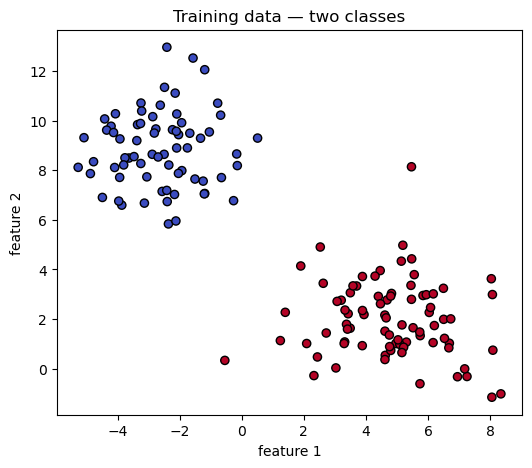

train: (150, 2)   test: (50, 2)


In [2]:
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.6, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', s=35)
plt.title('Training data — two classes')
plt.xlabel('feature 1'); plt.ylabel('feature 2')
plt.show()
print('train:', X_train.shape, '  test:', X_test.shape)

### The whole algorithm in two functions

1. **Distance** from the query point to every training point (Euclidean here).
2. **Vote**: take the `k` closest, return their majority label.

That's it — there is no “training” step. KNN simply *remembers* `X_train` and `y_train`.

In [3]:
def euclidean(point, others):
    """Distance from one point (n_features,) to every row in others (m, n_features)."""
    return np.sqrt(((others - point) ** 2).sum(axis=1))

def knn_predict(X_train, y_train, X_query, k=5):
    preds = []
    for x in X_query:
        dists = euclidean(x, X_train)        # distance to all training points
        nearest = np.argsort(dists)[:k]      # indices of the k closest
        votes = y_train[nearest]             # their labels
        labels, counts = np.unique(votes, return_counts=True)
        preds.append(labels[np.argmax(counts)])   # majority vote
    return np.array(preds)

# Predict on the held-out test set
y_pred = knn_predict(X_train, y_train, X_test, k=5)
accuracy = (y_pred == y_test).mean()
print(f'Our KNN accuracy (k=5): {accuracy:.3f}')

Our KNN accuracy (k=5): 1.000


### Sanity check against scikit-learn
If our from-scratch version is correct, it should match the library's implementation exactly.

In [4]:
sk = KNeighborsClassifier(n_neighbors=5)
sk.fit(X_train, y_train)
sk_pred = sk.predict(X_test)

print(f'scikit-learn accuracy (k=5): {(sk_pred == y_test).mean():.3f}')
print('Predictions identical to ours?', np.array_equal(sk_pred, y_pred))

scikit-learn accuracy (k=5): 1.000
Predictions identical to ours? True


### Choosing `k`: the bias–variance dial

- **Small k (k=1)** — jagged boundary that bends around every point. Low bias, **high variance**
  (it even wraps around noise/outliers).
- **Large k** — smooth boundary, **higher bias**. Too large and it just predicts the majority.

Watch the boundary change as we sweep `k`.

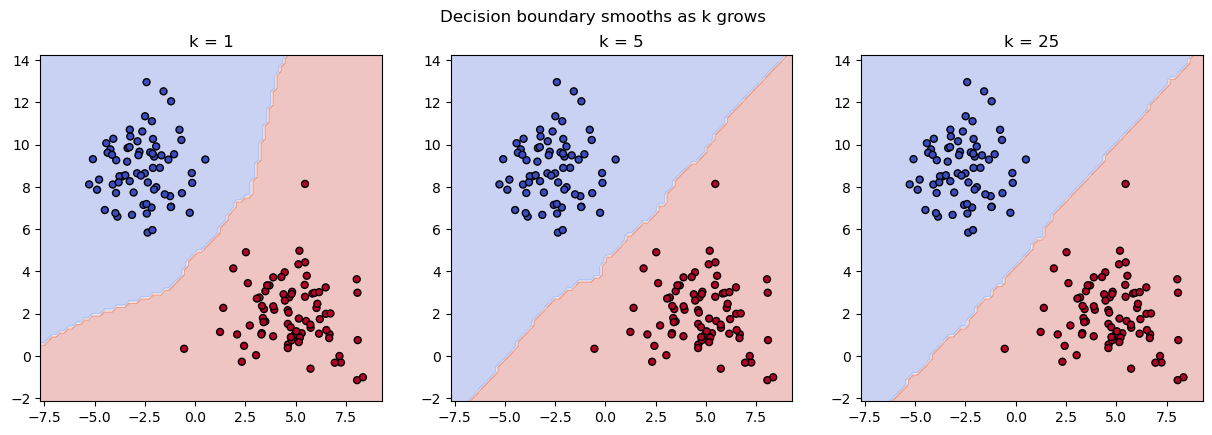

In [5]:
def plot_boundary(ax, k):
    h = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn_predict(X_train, y_train, grid, k).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', s=25)
    ax.set_title(f'k = {k}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axes, [1, 5, 25]):
    plot_boundary(ax, k)
plt.suptitle('Decision boundary smooths as k grows')
plt.show()

### ⚠️ Why feature scaling is mandatory for KNN

Distance is dominated by whatever feature has the **largest numeric range** — *regardless of how
useful that feature is*. To show this clearly we build a small dataset where:

- **feature 1** is the *informative* one (the two classes sit at different values), but it has a
  **small range**;
- **feature 2** is pure **noise** (no class information) but measured on a **large scale** — think
  “price in dollars” next to “rating out of 1”.

Raw Euclidean distance lets the large-scale noise drown out the useful feature. Standardizing
(mean 0, std 1) puts every feature on equal footing and rescues the accuracy.

In [6]:
rng = np.random.default_rng(0)
n = 150
# feature 1: informative but small range (classes centered at 0 vs 1)
f1 = np.concatenate([rng.normal(0.0, 0.15, n), rng.normal(1.0, 0.15, n)])
# feature 2: pure noise, but on a large scale (range ~0-1000)
f2 = rng.uniform(0, 1000, 2 * n)
Xs = np.column_stack([f1, f2])
ys = np.array([0] * n + [1] * n)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.3, random_state=0)

# 1) Raw features — large-scale noise dominates the distance
acc_raw = (knn_predict(Xs_tr, ys_tr, Xs_te, k=5) == ys_te).mean()

# 2) Standardize using the TRAINING mean/std only (never peek at test stats)
mu, sigma = Xs_tr.mean(axis=0), Xs_tr.std(axis=0)
acc_scaled = (knn_predict((Xs_tr - mu) / sigma, ys_tr, (Xs_te - mu) / sigma, k=5) == ys_te).mean()

print(f'Raw (noise feature on 0-1000 scale): {acc_raw:.3f}')
print(f'After standardizing:                 {acc_scaled:.3f}')

Raw (noise feature on 0-1000 scale): 0.489
After standardizing:                 1.000


---
# Part B — A mini neural network, from scratch

### The problem a straight line can't solve: XOR
Output is 1 only when the two inputs **differ**. No single straight line separates the 1s from
the 0s — so a single neuron (a perceptron) fails. We need a **hidden layer** to bend the space.

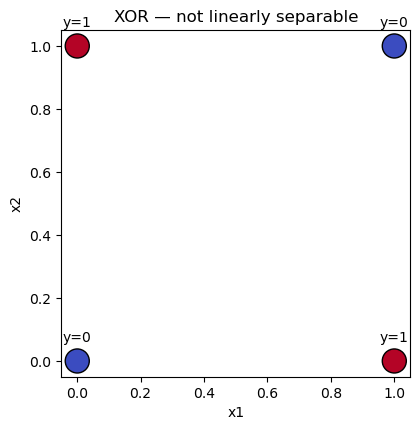

In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([[0], [1], [1], [0]], dtype=float)

plt.figure(figsize=(4.5, 4.5))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(), cmap='coolwarm', s=300, edgecolor='k')
for (a, b), t in zip(X_xor, y_xor.ravel()):
    plt.text(a, b + 0.06, f'y={int(t)}', ha='center')
plt.title('XOR — not linearly separable'); plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

### Architecture: 2 inputs → 4 hidden neurons → 1 output

Each neuron computes $z = Wx + b$ then a non-linear **activation** $a = \sigma(z)$.
We use the **sigmoid**, $\sigma(z) = 1/(1+e^{-z})$, whose derivative is conveniently $a(1-a)$.

Training is a loop of three steps:
1. **Forward pass** — push inputs through to a prediction.
2. **Backpropagation** — chain rule to get the gradient of the loss w.r.t. every weight.
3. **Update** — nudge each weight downhill: $w \leftarrow w - \eta\, \partial L/\partial w$.

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):          # a is already sigmoid(z)
    return a * (1 - a)

rng = np.random.default_rng(1)
# Weights: small random; biases start at zero
W1 = rng.normal(scale=1.0, size=(2, 4)); b1 = np.zeros((1, 4))
W2 = rng.normal(scale=1.0, size=(4, 1)); b2 = np.zeros((1, 1))

lr = 0.5
epochs = 5000
losses = []

for epoch in range(epochs):
    # --- forward pass ---
    a1 = sigmoid(X_xor @ W1 + b1)      # hidden activations  (4x4)
    a2 = sigmoid(a1 @ W2 + b2)         # output prediction   (4x1)

    # --- loss (mean squared error) ---
    loss = np.mean((y_xor - a2) ** 2)
    losses.append(loss)

    # --- backpropagation (chain rule) ---
    d2 = (a2 - y_xor) * sigmoid_deriv(a2)     # error at output
    dW2 = a1.T @ d2
    db2 = d2.sum(axis=0, keepdims=True)
    d1 = (d2 @ W2.T) * sigmoid_deriv(a1)       # error pushed back to hidden
    dW1 = X_xor.T @ d1
    db1 = d1.sum(axis=0, keepdims=True)

    # --- gradient descent update ---
    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

print(f'Final loss after {epochs} epochs: {losses[-1]:.5f}')

Final loss after 5000 epochs: 0.00058


### Did it learn XOR?
Predictions should round to the true labels `0, 1, 1, 0`, and the loss curve should fall toward 0.

Raw outputs: [0.019 0.976 0.978 0.03 ]
Rounded:     [0 1 1 0]
True labels: [0 1 1 0]


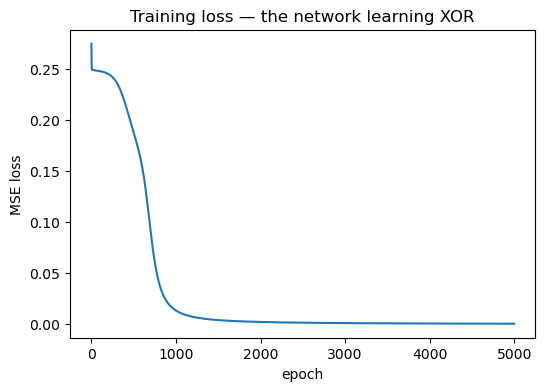

In [9]:
a1 = sigmoid(X_xor @ W1 + b1)
pred = sigmoid(a1 @ W2 + b2)
print('Raw outputs:', pred.ravel().round(3))
print('Rounded:    ', pred.ravel().round().astype(int))
print('True labels:', y_xor.ravel().astype(int))

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title('Training loss — the network learning XOR')
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.show()

### The boundary it learned
Unlike a single line, the hidden layer let the network carve a **non-linear** region — exactly
what XOR needs.

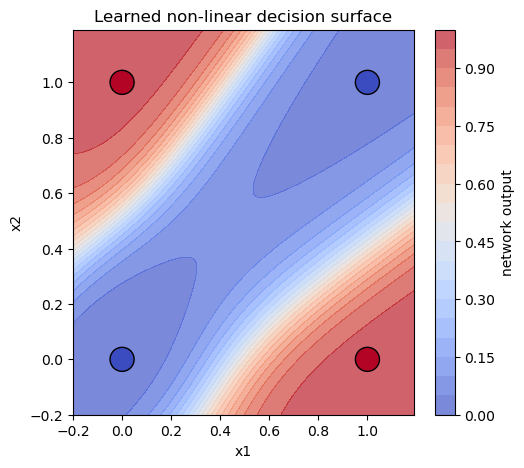

In [10]:
h = 0.01
xx, yy = np.meshgrid(np.arange(-0.2, 1.2, h), np.arange(-0.2, 1.2, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = sigmoid(sigmoid(grid @ W1 + b1) @ W2 + b2).reshape(xx.shape)

plt.figure(figsize=(5.5, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='network output')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(), cmap='coolwarm', s=300, edgecolor='k')
plt.title('Learned non-linear decision surface')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

---
## What we learned

- **KNN** does no training — it stores data and votes among neighbors at query time. Its only
  knobs are `k` and the distance metric, and it **demands feature scaling**.
- A **neural network** learns by repeatedly nudging weights to shrink a loss (gradient descent +
  backpropagation). A hidden layer with non-linear activations lets it model relationships a
  straight line cannot — like XOR.
- Same goal (classification), opposite philosophies: **memorize** vs **optimize parameters**.

### 🧪 Try it yourself
1. In the KNN section, change `cluster_std` to `3.0` so the blobs overlap. How does the best `k` change?
2. Set the mini-NN's hidden layer to **1 neuron** (`size=(2, 1)`). Can it still learn XOR? Why not?
3. Swap the sigmoid hidden activation for **ReLU** (`np.maximum(0, z)`) and adjust the backprop
   derivative. Does it train faster?
4. Lower the learning rate to `0.01`. How many more epochs do you need?

---
## 🔑 Solutions to the “Try it yourself” exercises

Worked answers below. Try the exercises first — then check here. The code reuses the functions
defined earlier (`knn_predict`, `sigmoid`, `X_xor`, …), so run the whole notebook top-to-bottom
before this section.

### 1. Overlapping blobs — how does the best `k` change?

With `cluster_std=3.0` the two classes overlap, so single neighbors are unreliable. We expect the
**best `k` to move higher**: small `k` overfits the noisy overlap region, larger `k` averages it out.

In [11]:
# Place the two cluster centers close together AND make them wide -> heavy overlap
Xo, yo = make_blobs(n_samples=300, centers=np.array([[0, 0], [3, 0]]),
                    cluster_std=2.5, random_state=42)
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(Xo, yo, test_size=0.3, random_state=42)

results = {}
for k in [1, 3, 5, 11, 21, 41]:
    acc = (knn_predict(Xo_tr, yo_tr, Xo_te, k) == yo_te).mean()
    results[k] = acc
    print(f'k={k:>2}  accuracy={acc:.3f}')

best_k = max(results, key=results.get)
print(f'\nBest k here = {best_k}  (k=1 only scored {results[1]:.3f})')

k= 1  accuracy=0.644
k= 3  accuracy=0.611
k= 5  accuracy=0.644
k=11  accuracy=0.700
k=21  accuracy=0.678
k=41  accuracy=0.744

Best k here = 41  (k=1 only scored 0.644)


**Takeaway:** on the clean, well-separated blobs from Part A almost any `k` scored ~1.0. But once
the classes overlap, the very small `k` values (which trust a single noisy neighbor) lose accuracy
and the sweet spot **shifts to a larger `k`** that averages over the messy region. This is the
bias–variance dial in action — noisier data needs more smoothing.

### A reusable training function (for exercises 2–4)

To answer the next three cleanly we wrap the training loop in one function, parameterised by the
**hidden size, activation, learning rate, and epochs**. The output neuron stays sigmoid (we want a
0–1 prediction); only the *hidden* activation changes.

In [12]:
def relu(z):
    return np.maximum(0, z)

def train_net(hidden=4, activation='sigmoid', lr=0.5, epochs=5000, seed=1):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(scale=1.0, size=(2, hidden)); b1 = np.zeros((1, hidden))
    W2 = rng.normal(scale=1.0, size=(hidden, 1)); b2 = np.zeros((1, 1))

    def act(z):       return relu(z) if activation == 'relu' else sigmoid(z)
    def act_grad(a, z):
        return (z > 0).astype(float) if activation == 'relu' else sigmoid_deriv(a)

    losses = []
    for _ in range(epochs):
        z1 = X_xor @ W1 + b1; a1 = act(z1)
        a2 = sigmoid(a1 @ W2 + b2)              # output always sigmoid
        losses.append(np.mean((y_xor - a2) ** 2))

        d2 = (a2 - y_xor) * sigmoid_deriv(a2)
        dW2 = a1.T @ d2; db2 = d2.sum(0, keepdims=True)
        d1 = (d2 @ W2.T) * act_grad(a1, z1)
        dW1 = X_xor.T @ d1; db1 = d1.sum(0, keepdims=True)
        W2 -= lr * dW2; b2 -= lr * db2; W1 -= lr * dW1; b1 -= lr * db1

    final = sigmoid(act(X_xor @ W1 + b1) @ W2 + b2).ravel()
    return np.array(losses), final

def epoch_reaching(losses, thresh=0.01):
    hit = np.where(losses < thresh)[0]
    return int(hit[0]) if len(hit) else None

### 2. One hidden neuron — can it learn XOR?

**No.** XOR needs the input space bent in two separate places; a single hidden neuron only gives
you *one* curved boundary — not enough. Compare the runs below: with 1 hidden neuron the loss
plateaus far higher than with 4, and it **collapses several corners onto the same output**, getting
at least one of the four cases wrong. You need **at least two** hidden neurons to represent XOR.

In [13]:
loss1, pred1 = train_net(hidden=1, epochs=5000)
loss4, pred4 = train_net(hidden=4, epochs=5000)

print(f'1 hidden neuron : final loss {loss1[-1]:.3f}  preds {pred1.round(2)}')
print(f'4 hidden neurons: final loss {loss4[-1]:.3f}  preds {pred4.round(2)}')
print('\nTrue labels    :', y_xor.ravel().astype(int))

1 hidden neuron : final loss 0.168  preds [0.03 0.67 0.67 0.67]
4 hidden neurons: final loss 0.001  preds [0.02 0.98 0.98 0.03]

True labels    : [0 1 1 0]


### 3. Swap sigmoid → ReLU in the hidden layer

ReLU's gradient is simply 1 where `z > 0` and 0 otherwise (no vanishing-gradient squashing), so it
often reaches a low loss in **fewer epochs**. ReLU prefers a smaller learning rate here to stay
stable. We compare how quickly each crosses loss < 0.01.

sigmoid reached loss<0.01 at epoch 1086
relu    reached loss<0.01 at epoch 555


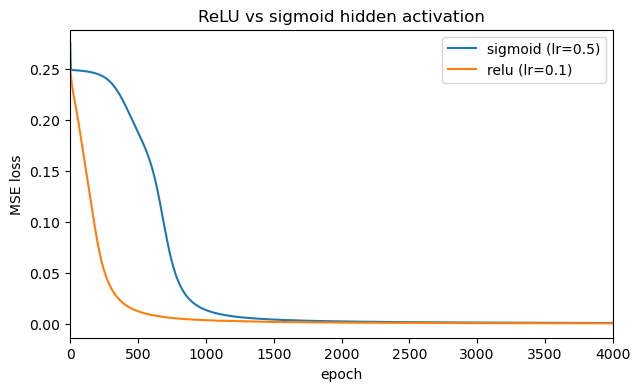

In [14]:
loss_sig, _ = train_net(activation='sigmoid', lr=0.5, epochs=20000, seed=1)
loss_relu, _ = train_net(activation='relu',   lr=0.1, epochs=20000, seed=1)

print('sigmoid reached loss<0.01 at epoch', epoch_reaching(loss_sig))
print('relu    reached loss<0.01 at epoch', epoch_reaching(loss_relu))

plt.figure(figsize=(7, 4))
plt.plot(loss_sig, label='sigmoid (lr=0.5)')
plt.plot(loss_relu, label='relu (lr=0.1)')
plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.legend()
plt.title('ReLU vs sigmoid hidden activation'); plt.xlim(0, 4000)
plt.show()

### 4. Drop the learning rate to 0.01 — how many more epochs?

The learning rate scales every weight update, so cutting it ~50× means each step is tiny and you
need far more steps to cover the same ground. Roughly, **epochs scale inversely with the learning
rate**.

In [15]:
loss_fast, _ = train_net(lr=0.5,  epochs=80000, seed=1)
loss_slow, _ = train_net(lr=0.01, epochs=80000, seed=1)

e_fast = epoch_reaching(loss_fast)
e_slow = epoch_reaching(loss_slow)
print(f'lr=0.5  reached loss<0.01 at epoch {e_fast}')
print(f'lr=0.01 reached loss<0.01 at epoch {e_slow}')
if e_fast and e_slow:
    print(f'\n~{e_slow / e_fast:.0f}x more epochs needed at the lower learning rate.')

lr=0.5  reached loss<0.01 at epoch 1086
lr=0.01 reached loss<0.01 at epoch 54248

~50x more epochs needed at the lower learning rate.


**Takeaway:** a smaller learning rate is *safer* (less chance of overshooting) but *slower*. Too
large and the loss can oscillate or diverge; too small and training crawls. Tuning it is one of the
most important parts of training neural networks.